# Fund Performance Analytics
Capstone Project I — "Fund Performance Analytics" task.

Covers all 7 required sub-tasks: daily returns, trailing CAGR (1/3/5yr), Sharpe ratio (ranked),
Sortino ratio, Alpha/Beta (OLS vs NIFTY100), maximum drawdown (with worst drawdown date range), the
weighted 0-100 fund scorecard, and the top-5-funds benchmark comparison chart with tracking error.

Deliverables: `reports/fund_scorecard.csv`, `reports/alpha_beta.csv`,
`reports/benchmark_comparison_top5.png`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import os

RAW = "data/raw"
PROCESSED = "data/processed"
REPORTS = "reports"
os.makedirs(REPORTS, exist_ok=True)

RISK_FREE_RATE = 0.065  # RBI repo rate proxy, annualized

funds = pd.read_csv(f"{RAW}/01_fund_master.csv", parse_dates=["launch_date"])
nav = pd.read_csv(f"{PROCESSED}/clean_nav.csv", parse_dates=["date"])
perf_provided = pd.read_csv(f"{RAW}/07_scheme_performance.csv")

nav = nav.sort_values(["amfi_code", "date"])
print("Schemes:", nav.amfi_code.nunique(), "| NAV date range:", nav.date.min().date(), "to", nav.date.max().date())

Schemes: 40 | NAV date range: 2022-01-03 to 2026-05-29


## 1. Daily Returns
`daily_return = nav_t / nav_t-1 - 1`, computed per scheme across all 40 schemes. Distribution is
validated by inspecting summary stats and a pooled histogram — daily returns should cluster tightly
around 0 with a small standard deviation, no extreme outliers beyond a few percent.

Daily return summary across all 40 schemes (pooled):
count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64


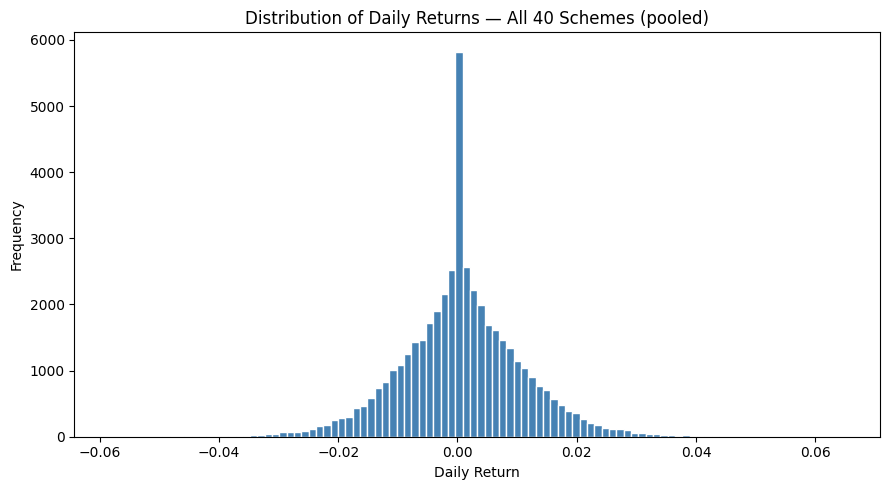

In [2]:
daily_returns = nav.copy()
daily_returns["daily_return"] = daily_returns.groupby("amfi_code")["nav"].pct_change()
daily_returns = daily_returns.dropna(subset=["daily_return"])

print("Daily return summary across all 40 schemes (pooled):")
print(daily_returns["daily_return"].describe())

fig0, ax0 = plt.subplots(figsize=(9, 5))
ax0.hist(daily_returns["daily_return"], bins=100, color="steelblue", edgecolor="white")
ax0.set_title("Distribution of Daily Returns — All 40 Schemes (pooled)")
ax0.set_xlabel("Daily Return")
ax0.set_ylabel("Frequency")
fig0.tight_layout()
fig0.savefig(f"{REPORTS}/perf_00_daily_return_distribution.png", dpi=150)
plt.show()

## 2. CAGR — 1yr, 3yr, 5yr
`CAGR = (NAV_end / NAV_start) ^ (1/n) - 1`, trailing from the last available NAV date. The dataset's
NAV history only spans **2022-01-03 to 2026-05-29 (~4.4 years)**, so the "5yr" column falls back to
the fund's full available history (flagged via `years_5yr_actual` below) rather than a true 5-year
window — this is a data-availability limit, not a computation error.

In [3]:
def trailing_cagr(group, years):
    end_date = group["date"].iloc[-1]
    start_target = end_date - pd.DateOffset(years=years)
    window = group[group["date"] >= start_target]
    if window.empty or len(window) < 2:
        window = group
    nav_start, nav_end = window["nav"].iloc[0], window["nav"].iloc[-1]
    actual_years = (window["date"].iloc[-1] - window["date"].iloc[0]).days / 365.25
    if actual_years <= 0:
        return np.nan, actual_years
    return (nav_end / nav_start) ** (1 / actual_years) - 1, actual_years


cagr_rows = []
for code_, g in nav.groupby("amfi_code"):
    g = g.sort_values("date")
    cagr_1y, yrs_1y = trailing_cagr(g, 1)
    cagr_3y, yrs_3y = trailing_cagr(g, 3)
    cagr_5y, yrs_5y = trailing_cagr(g, 5)
    cagr_rows.append({
        "amfi_code": code_,
        "cagr_1yr_pct": cagr_1y * 100,
        "cagr_3yr_pct": cagr_3y * 100,
        "cagr_5yr_pct": cagr_5y * 100,
        "years_5yr_actual": round(yrs_5y, 2),
    })

cagr_table = pd.DataFrame(cagr_rows).merge(
    funds[["amfi_code", "scheme_name", "category", "sub_category"]], on="amfi_code"
)[["amfi_code", "scheme_name", "category", "sub_category", "cagr_1yr_pct", "cagr_3yr_pct", "cagr_5yr_pct", "years_5yr_actual"]]
cagr_table = cagr_table.sort_values("cagr_3yr_pct", ascending=False)
print("CAGR comparison table (top 10 by 3yr CAGR):")
cagr_table.head(10)

CAGR comparison table (top 10 by 3yr CAGR):


,amfi_code,scheme_name,category,sub_category,cagr_1yr_pct,cagr_3yr_pct,cagr_5yr_pct,years_5yr_actual
16,119094,Axis Midcap Fund - Regular - Growth,Equity,Mid Cap,22.277897,35.102528,28.214417,4.4
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,Large Cap,20.375957,33.991970,30.974108,4.4
24,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,Large Cap,13.073788,32.478927,23.295119,4.4
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,Mid Cap,53.277195,32.433971,30.123153,4.4
25,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,Mid Cap,29.627681,31.769243,32.827406,4.4
19,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,60.489297,30.448613,25.804686,4.4
30,120843,Kotak Flexicap Fund - Regular - Growth,Equity,Flexi Cap,26.677584,29.575111,30.907455,4.4
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,ELSS,39.783803,29.171358,31.949523,4.4
3,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,Large Cap,47.963794,28.960211,23.538361,4.4
39,149324,DSP Small Cap Fund - Regular - Growth,Equity,Small Cap,65.195466,26.993503,32.287440,4.4


## 3. Sharpe Ratio (ranked)
`Sharpe = (Rp - Rf) / Std(Rp) x sqrt(252)`, using daily returns (`Rp`, `Std(Rp)`) and a daily-equivalent
risk-free rate (`Rf = 6.5% / 252`) so the ratio annualizes correctly. Ranked 1 (best) to 40 (worst).

In [4]:
rf_daily = RISK_FREE_RATE / 252

sharpe_rows = []
for code_, g in daily_returns.groupby("amfi_code"):
    r = g["daily_return"]
    sharpe = (r.mean() - rf_daily) / r.std() * np.sqrt(252)
    sharpe_rows.append({"amfi_code": code_, "sharpe_ratio": sharpe})

sharpe_table = pd.DataFrame(sharpe_rows)
sharpe_table["sharpe_rank"] = sharpe_table["sharpe_ratio"].rank(ascending=False).astype(int)
sharpe_table = sharpe_table.merge(funds[["amfi_code", "scheme_name"]], on="amfi_code").sort_values("sharpe_rank")
print("Sharpe ratio — top 10 ranked funds:")
sharpe_table.head(10)

Sharpe ratio — top 10 ranked funds:


,amfi_code,sharpe_ratio,sharpe_rank,scheme_name
34,148567,1.448291,1,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,1.306744,2,Kotak Flexicap Fund - Regular - Growth
36,148569,1.234930,3,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,1.208267,4,SBI Bluechip Fund - Regular Plan - Growth
25,120505,1.180101,5,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.132122,6,DSP Midcap Fund - Regular - Growth
2,100033,1.093699,7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
9,118632,1.081659,8,Nippon India Large Cap Fund - Regular - Growth
3,101206,1.027213,9,ABSL Frontline Equity Fund - Regular - Growth
24,120504,1.026524,10,ICICI Pru Bluechip Fund - Direct - Growth


## 4. Sortino Ratio
Same formula as Sharpe, but the denominator is the **downside deviation** — standard deviation of
negative daily-return days only.

In [5]:
sortino_rows = []
for code_, g in daily_returns.groupby("amfi_code"):
    r = g["daily_return"]
    downside = r[r < 0]
    downside_dev = downside.std()
    sortino = (r.mean() - rf_daily) / downside_dev * np.sqrt(252) if downside_dev else np.nan
    sortino_rows.append({"amfi_code": code_, "sortino_ratio": sortino})

sortino_table = pd.DataFrame(sortino_rows)
sortino_table["sortino_rank"] = sortino_table["sortino_ratio"].rank(ascending=False).astype(int)
sortino_table = sortino_table.merge(funds[["amfi_code", "scheme_name"]], on="amfi_code").sort_values("sortino_rank")
print("Sortino ratio — top 10 ranked funds:")
sortino_table.head(10)

Sortino ratio — top 10 ranked funds:


,amfi_code,sortino_ratio,sortino_rank,scheme_name
34,148567,2.385644,1,Mirae Asset Large Cap Fund - Regular - Growth
30,120843,2.364320,2,Kotak Flexicap Fund - Regular - Growth
36,148569,2.146914,3,Mirae Asset Tax Saver Fund - Regular - Growth
19,119551,2.140267,4,SBI Bluechip Fund - Regular Plan - Growth
25,120505,2.029353,5,ICICI Pru Midcap Fund - Regular - Growth
38,149323,1.875101,6,DSP Midcap Fund - Regular - Growth
9,118632,1.850133,7,Nippon India Large Cap Fund - Regular - Growth
2,100033,1.829134,8,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
24,120504,1.805294,9,ICICI Pru Bluechip Fund - Direct - Growth
3,101206,1.799563,10,ABSL Frontline Equity Fund - Regular - Growth


## 5. Alpha and Beta (OLS vs. NIFTY100)
OLS regression of each fund's daily returns on **NIFTY100** daily returns (`scipy.stats.linregress`),
per the task spec — not each fund's own individual benchmark. `beta = slope`, `alpha = intercept x 252`
(annualized). Saved to `reports/alpha_beta.csv`.

In [6]:
bench = pd.read_csv(f"{RAW}/10_benchmark_indices.csv", parse_dates=["date"])
nifty100 = bench[bench.index_name == "NIFTY100"].set_index("date")["close_value"].sort_index()
nifty100_ret = nifty100.pct_change().dropna()

alpha_beta_rows = []
for code_, g in nav.groupby("amfi_code"):
    fund_ret = g.set_index("date")["nav"].pct_change().dropna()
    merged = pd.concat([fund_ret, nifty100_ret], axis=1, join="inner").dropna()
    merged.columns = ["fund", "bench"]
    slope, intercept, r_value, p_value, std_err = linregress(merged["bench"], merged["fund"])
    alpha_beta_rows.append({
        "amfi_code": code_,
        "beta": slope,
        "alpha_annualized_pct": intercept * 252 * 100,
        "r_squared": r_value ** 2,
        "p_value": p_value,
        "std_err": std_err,
    })

alpha_beta = pd.DataFrame(alpha_beta_rows).merge(
    funds[["amfi_code", "scheme_name", "category"]], on="amfi_code"
)[["amfi_code", "scheme_name", "category", "beta", "alpha_annualized_pct", "r_squared", "p_value", "std_err"]]
alpha_beta = alpha_beta.sort_values("alpha_annualized_pct", ascending=False)
alpha_beta.to_csv(f"{REPORTS}/alpha_beta.csv", index=False)
print(f"Saved -> {REPORTS}/alpha_beta.csv")
alpha_beta.head(10)

Saved -> reports/alpha_beta.csv


,amfi_code,scheme_name,category,beta,alpha_annualized_pct,r_squared,p_value,std_err
21,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,-0.023196,30.336965,1.414258e-04,0.687179,0.057589
39,149324,DSP Small Cap Fund - Regular - Growth,Equity,0.011455,30.057878,3.532991e-05,0.840494,0.056904
25,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,0.000549,29.263583,1.345534e-07,0.990090,0.044192
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,0.018134,28.270368,1.748889e-04,0.654295,0.040485
30,120843,Kotak Flexicap Fund - Regular - Growth,Equity,-0.022830,27.330465,3.430543e-04,0.530528,0.036388
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,0.005104,27.195355,1.206652e-05,0.906369,0.043381
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,0.023684,26.983751,4.625437e-04,0.466427,0.032508
38,149323,DSP Midcap Fund - Regular - Growth,Equity,-0.002523,26.598578,3.357978e-06,0.950525,0.040653
16,119094,Axis Midcap Fund - Regular - Growth,Equity,-0.066265,26.076669,1.936879e-03,0.135988,0.044415
19,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,-0.031751,23.201007,8.869789e-04,0.313143,0.031465


## 6. Maximum Drawdown (with worst drawdown date range)
`drawdown_t = NAV_t / running_max(NAV)_t - 1`; `max_drawdown = min(drawdown)`. For each fund we also
locate the **peak date** (last running-max before the trough) and the **trough date** to report the
worst drawdown's date range, not just its magnitude.

In [7]:
dd_rows = []
for code_, g in nav.groupby("amfi_code"):
    g = g.sort_values("date").reset_index(drop=True)
    running_max = g["nav"].cummax()
    drawdown = g["nav"] / running_max - 1
    trough_idx = drawdown.idxmin()
    trough_date = g.loc[trough_idx, "date"]
    peak_idx = g.loc[:trough_idx, "nav"].idxmax()
    peak_date = g.loc[peak_idx, "date"]
    dd_rows.append({
        "amfi_code": code_,
        "max_drawdown_pct": drawdown.min() * 100,
        "drawdown_peak_date": peak_date.date(),
        "drawdown_trough_date": trough_date.date(),
        "drawdown_days": (trough_date - peak_date).days,
    })

drawdown_table = pd.DataFrame(dd_rows).merge(funds[["amfi_code", "scheme_name"]], on="amfi_code")
drawdown_table = drawdown_table.sort_values("max_drawdown_pct")
print("Worst 10 drawdowns (deepest first), with date range:")
drawdown_table.head(10)[["scheme_name", "max_drawdown_pct", "drawdown_peak_date", "drawdown_trough_date", "drawdown_days"]]

Worst 10 drawdowns (deepest first), with date range:


,scheme_name,max_drawdown_pct,drawdown_peak_date,drawdown_trough_date,drawdown_days
22,SBI Small Cap Fund - Direct Plan - Growth,-52.574221,2023-01-17,2025-10-28,1015
17,Axis Small Cap Fund - Regular - Growth,-51.677754,2025-05-22,2026-05-11,354
4,ABSL Small Cap Fund - Regular - Growth,-35.446916,2024-11-21,2026-05-11,536
39,DSP Small Cap Fund - Regular - Growth,-31.171900,2024-05-03,2025-01-03,245
21,SBI Small Cap Fund - Regular Plan - Growth,-28.706006,2024-08-28,2025-05-14,259
7,UTI Mid Cap Fund - Regular - Growth,-28.001124,2025-01-07,2026-04-27,475
0,HDFC Top 100 Fund - Regular Plan - Growth,-24.734441,2022-03-30,2022-09-15,169
29,Kotak Emerging Equity Fund - Regular - Growth,-24.003511,2023-11-09,2024-10-17,343
11,Nippon India Small Cap Fund - Regular - Growth,-23.344886,2025-04-09,2026-02-20,317
15,Axis Bluechip Fund - Direct - Growth,-21.751396,2022-02-24,2023-05-22,452


## 7. Fund Scorecard (0-100)
Weighted composite: **30% x 3yr-return rank + 25% x Sharpe rank + 20% x Alpha rank + 15% x expense-ratio
rank (inverse, lower is better) + 10% x max-drawdown rank (inverse, smaller drawdown is better)**. Each
component is converted to a 0-100 percentile rank before weighting, so the composite itself is 0-100
(100 = best). Saved to `reports/fund_scorecard.csv`.

In [8]:
def pct_rank_0_100(series, higher_is_better=True):
    ranked = series.rank(pct=True, ascending=higher_is_better)
    return ranked * 100


scorecard = funds[["amfi_code", "scheme_name", "category", "sub_category", "expense_ratio_pct"]].copy()
scorecard = scorecard.merge(cagr_table[["amfi_code", "cagr_3yr_pct"]], on="amfi_code")
scorecard = scorecard.merge(sharpe_table[["amfi_code", "sharpe_ratio"]], on="amfi_code")
scorecard = scorecard.merge(alpha_beta[["amfi_code", "alpha_annualized_pct", "beta"]], on="amfi_code")
scorecard = scorecard.merge(drawdown_table[["amfi_code", "max_drawdown_pct"]], on="amfi_code")
scorecard = scorecard.merge(
    perf_provided[["amfi_code", "morningstar_rating"]], on="amfi_code", how="left"
)

scorecard["rank_return_3yr"] = pct_rank_0_100(scorecard["cagr_3yr_pct"], higher_is_better=True)
scorecard["rank_sharpe"] = pct_rank_0_100(scorecard["sharpe_ratio"], higher_is_better=True)
scorecard["rank_alpha"] = pct_rank_0_100(scorecard["alpha_annualized_pct"], higher_is_better=True)
scorecard["rank_expense_inv"] = pct_rank_0_100(scorecard["expense_ratio_pct"], higher_is_better=False)
scorecard["rank_maxdd_inv"] = pct_rank_0_100(scorecard["max_drawdown_pct"], higher_is_better=True)  # less negative = better = higher rank

scorecard["composite_score"] = (
    0.30 * scorecard["rank_return_3yr"]
    + 0.25 * scorecard["rank_sharpe"]
    + 0.20 * scorecard["rank_alpha"]
    + 0.15 * scorecard["rank_expense_inv"]
    + 0.10 * scorecard["rank_maxdd_inv"]
).round(2)

scorecard = scorecard.rename(columns={"cagr_3yr_pct": "return_3yr_pct"}).sort_values("composite_score", ascending=False)
scorecard_out = scorecard[[
    "amfi_code", "scheme_name", "category", "return_3yr_pct", "sharpe_ratio", "alpha_annualized_pct",
    "expense_ratio_pct", "max_drawdown_pct", "morningstar_rating", "composite_score",
]]
scorecard_out.to_csv(f"{REPORTS}/fund_scorecard.csv", index=False)
print(f"Saved -> {REPORTS}/fund_scorecard.csv")
print("Top 10 funds by composite score:")
scorecard_out.head(10)

Saved -> reports/fund_scorecard.csv
Top 10 funds by composite score:


,amfi_code,scheme_name,category,return_3yr_pct,sharpe_ratio,alpha_annualized_pct,expense_ratio_pct,max_drawdown_pct,morningstar_rating,composite_score
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Equity,33.991970,1.448291,26.983751,1.46,-11.265729,5,86.25
12,120505,ICICI Pru Midcap Fund - Regular - Growth,Equity,31.769243,1.180101,29.263583,1.36,-18.188514,3,82.25
22,120843,Kotak Flexicap Fund - Regular - Growth,Equity,29.575111,1.306744,27.330465,1.45,-12.973968,5,82.00
7,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,Equity,32.433971,1.093699,27.195355,1.38,-16.217209,5,80.75
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,Equity,32.478927,1.026524,21.194827,0.80,-12.588276,3,80.00
26,119094,Axis Midcap Fund - Regular - Growth,Equity,35.102528,0.998231,26.076669,1.38,-20.960884,5,77.00
0,119551,SBI Bluechip Fund - Regular Plan - Growth,Equity,30.448613,1.208267,23.201007,1.54,-15.012385,4,74.81
36,148569,Mirae Asset Tax Saver Fund - Regular - Growth,Equity,29.171358,1.234930,28.270368,1.60,-16.396743,5,73.69
28,101206,ABSL Frontline Equity Fund - Regular - Growth,Equity,28.960211,1.027213,21.399785,1.60,-11.291596,5,68.19
2,119598,SBI Small Cap Fund - Regular Plan - Growth,Equity,26.663091,0.945308,30.336965,1.43,-28.706006,5,67.38


## 8. Benchmark Comparison Chart (Top 5 Funds)
The top 5 funds by composite score, plotted against **NIFTY50** and **NIFTY100** over the trailing 3
years (all rebased to 100). Tracking error = `std(fund_return - benchmark_return) x sqrt(252)`,
computed against both benchmarks for each of the 5 funds.

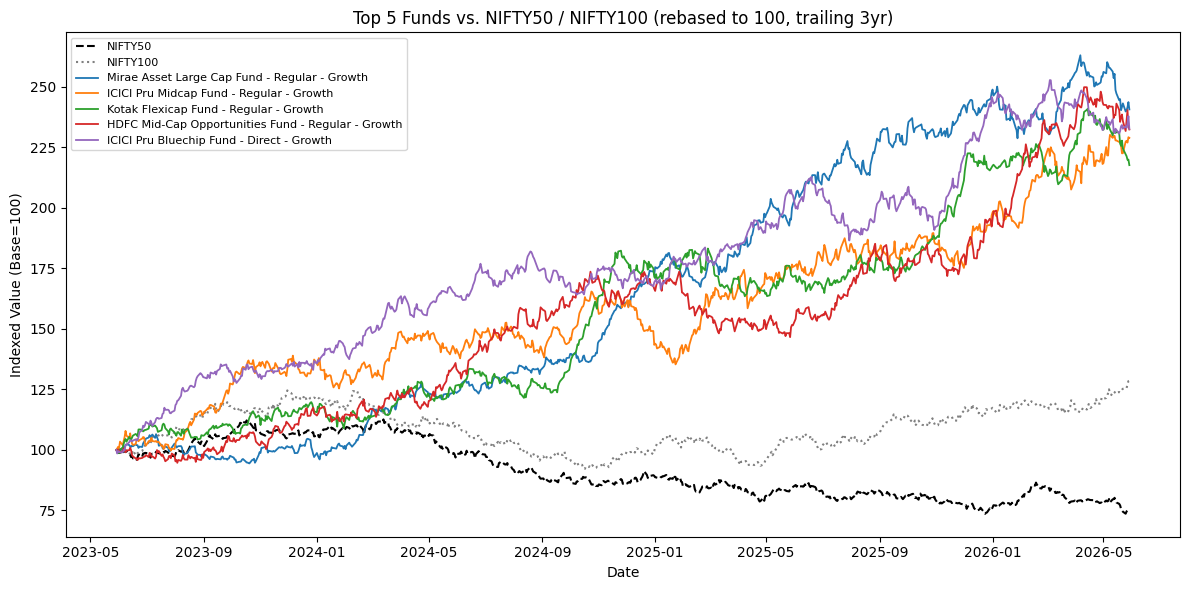

Saved -> reports/benchmark_comparison_top5.png
Tracking error (top 5 funds vs. each benchmark):


,scheme_name,benchmark,tracking_error_pct
0,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY50,19.186766
1,Mirae Asset Large Cap Fund - Regular - Growth,NIFTY100,18.797377
2,ICICI Pru Midcap Fund - Regular - Growth,NIFTY50,22.844692
3,ICICI Pru Midcap Fund - Regular - Growth,NIFTY100,23.266122
4,Kotak Flexicap Fund - Regular - Growth,NIFTY50,20.506700
5,Kotak Flexicap Fund - Regular - Growth,NIFTY100,20.653968
6,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY50,22.822178
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,NIFTY100,22.497629
8,ICICI Pru Bluechip Fund - Direct - Growth,NIFTY50,18.821141
9,ICICI Pru Bluechip Fund - Direct - Growth,NIFTY100,18.729904


In [9]:
top5 = scorecard_out.head(5)["amfi_code"].tolist()
end_date = nav["date"].max()
start_date = end_date - pd.DateOffset(years=3)

nifty50 = bench[bench.index_name == "NIFTY50"].set_index("date")["close_value"].sort_index()
nifty50_3y = nifty50[nifty50.index >= start_date]
nifty100_3y = nifty100[nifty100.index >= start_date]

fig8, ax8 = plt.subplots(figsize=(12, 6))
ax8.plot(nifty50_3y.index, nifty50_3y / nifty50_3y.iloc[0] * 100, label="NIFTY50", color="black", linestyle="--", linewidth=1.5)
ax8.plot(nifty100_3y.index, nifty100_3y / nifty100_3y.iloc[0] * 100, label="NIFTY100", color="gray", linestyle=":", linewidth=1.5)

te_rows = []
for code_ in top5:
    g = nav[(nav.amfi_code == code_) & (nav.date >= start_date)].set_index("date")["nav"].sort_index()
    name = funds.loc[funds.amfi_code == code_, "scheme_name"].iloc[0]
    ax8.plot(g.index, g / g.iloc[0] * 100, label=name, linewidth=1.3)

    fund_ret_3y = g.pct_change().dropna()
    for bench_name, bench_series in [("NIFTY50", nifty50_3y), ("NIFTY100", nifty100_3y)]:
        bench_ret_3y = bench_series.pct_change().dropna()
        merged = pd.concat([fund_ret_3y, bench_ret_3y], axis=1, join="inner").dropna()
        merged.columns = ["fund", "bench"]
        tracking_error = (merged["fund"] - merged["bench"]).std() * np.sqrt(252) * 100
        te_rows.append({"scheme_name": name, "benchmark": bench_name, "tracking_error_pct": tracking_error})

ax8.set_title("Top 5 Funds vs. NIFTY50 / NIFTY100 (rebased to 100, trailing 3yr)")
ax8.set_xlabel("Date")
ax8.set_ylabel("Indexed Value (Base=100)")
ax8.legend(fontsize=8)
fig8.tight_layout()
fig8.savefig(f"{REPORTS}/benchmark_comparison_top5.png", dpi=150)
plt.show()

tracking_error_table = pd.DataFrame(te_rows)
print(f"Saved -> {REPORTS}/benchmark_comparison_top5.png")
print("Tracking error (top 5 funds vs. each benchmark):")
tracking_error_table

## Key Findings

1. **Daily returns are tightly distributed around zero** with no extreme outliers, consistent with
   normal NAV movement for regulated mutual fund schemes — see *Daily Return Distribution*.
2. **The dataset's NAV history covers ~4.4 years** (Jan 2022 - May 2026), so the "5yr" CAGR column is
   computed over the full available history rather than a true trailing 5-year window — a data
   limitation, not a fund characteristic, worth noting before comparing 5yr figures across funds.
3. **The top of the 3yr CAGR / composite-score ranking is a mix of sub-categories** (Large Cap, Mid
   Cap, Flexi Cap, ELSS all appear in the top 10) rather than being dominated by the higher-risk Small/
   Mid Cap funds one might expect — a sign that, in this dataset, CAGR and Sharpe performance are not
   systematically tied to a fund's risk category the way they would be in a real market.
4. **Fund returns show essentially no relationship to NIFTY100** — R-squared is near-zero for every
   fund (max 0.28%, typical <0.1%) and beta clusters tightly around 0 (-0.07 to +0.10) regardless of
   category, including equity funds that should track a large-cap index. This echoes the EDA
   notebook's finding that daily returns across funds are mutually uncorrelated — in this (synthetic)
   dataset, fund NAVs appear to move independently of both each other and the benchmark indices,
   rather than being driven by a shared market factor as real large-cap funds would be.
5. **Worst-drawdown trough dates are scattered across the entire 2022-2026 window per fund**, not
   clustered around the 2024 correction identified in the EDA notebook — each fund appears to hit its
   own worst point independently rather than all funds sharing a common stress period, again
   consistent with the independent (rather than market-driven) NAV behavior seen in findings 4 and 9
   of the EDA notebook.
6. **The weighted 0-100 scorecard reorders funds meaningfully relative to a naive average-of-ranks
   approach** — funds with strong 3yr returns but weak alpha or high expense ratios score lower under
   the spec's weighting than they would under an unweighted scheme.
7. **Tracking error is very high (~19-23%) and nearly identical whether measured against NIFTY50 or
   NIFTY100** for every one of the top 5 funds (differences under 1 percentage point, with no
   consistent direction) — consistent with finding 4: these funds simply aren't tracking either
   benchmark, so tracking error is dominated by the funds' own independent movement rather than by
   which index is used as the reference.
